# Figure Size and Resolution in Data Visualization

This notebook explores techniques for controlling the dimensions and quality of data visualizations in Python. We'll cover how to set appropriate figure sizes, adjust resolution parameters, and prepare visualizations for different output formats.

## Import Required Libraries

In [1]:
# Import essential visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.figure import Figure
from IPython.display import display, HTML

# Set the default style for better aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook")

# For displaying images directly
from IPython.display import Image

print(f"Matplotlib version: {mpl.__version__}")
print(f"Seaborn version: {sns.__version__}")

Matplotlib version: 3.10.1
Seaborn version: 0.13.2


## Understanding Figure Size Parameters

In Matplotlib, figure size refers to the dimensions of the plot canvas. The size is specified in inches and affects how your visualization appears. Setting an appropriate figure size is crucial for:

1. Ensuring your visualization is legible
2. Maintaining proper proportions for your data
3. Fitting the intended display medium (screen, print, etc.)

The primary way to control figure size is through the `figsize` parameter, which takes a tuple of `(width, height)` in inches.

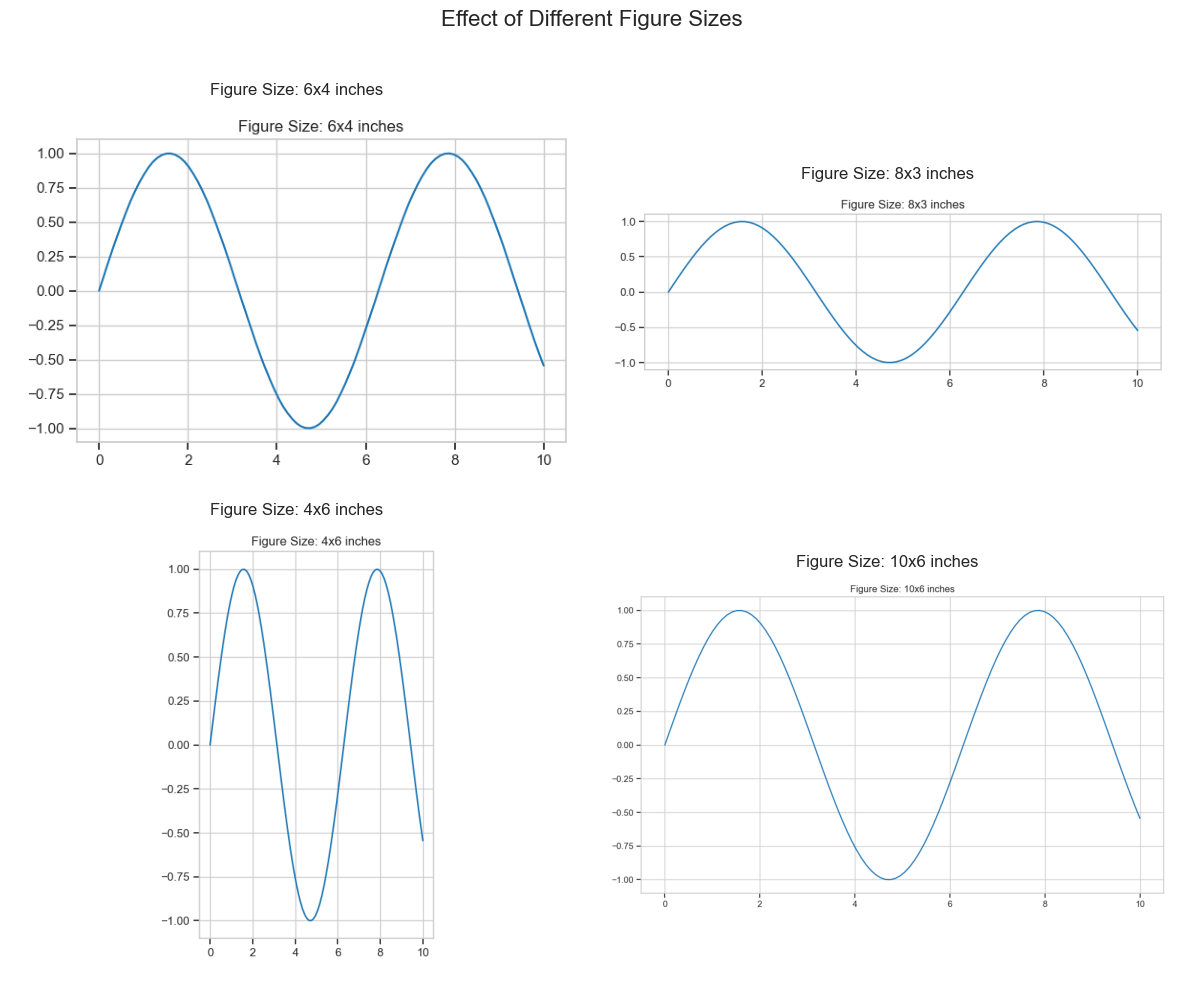

In [2]:
# Create a sample dataset
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Demonstrate different figure sizes
fig_sizes = [(6, 4), (8, 3), (4, 6), (10, 6)]

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

for i, size in enumerate(fig_sizes):
    # Create a new figure with specific size
    plt.figure(figsize=size)
    plt.plot(x, y)
    plt.title(f"Figure Size: {size[0]}x{size[1]} inches")
    plt.tight_layout()
    
    # Save to display in our main figure
    plt.savefig(f"temp_fig_size_{i}.png")
    plt.close()
    
    # Show in the main figure
    img = plt.imread(f"temp_fig_size_{i}.png")
    axs[i].imshow(img)
    axs[i].set_title(f"Figure Size: {size[0]}x{size[1]} inches")
    axs[i].axis('off')

plt.suptitle("Effect of Different Figure Sizes", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

### Key Points About Figure Size

- **Default Size**: The default figure size in Matplotlib is `(6.4, 4.8)` inches
- **Aspect Ratio**: Figure size affects the aspect ratio, which can distort visualizations if not set appropriately
- **Content Density**: Larger figures can accommodate more details and annotations
- **Jupyter Considerations**: Figure sizes may appear different in Jupyter notebooks compared to saved images

Let's see how figure size affects different types of plots:

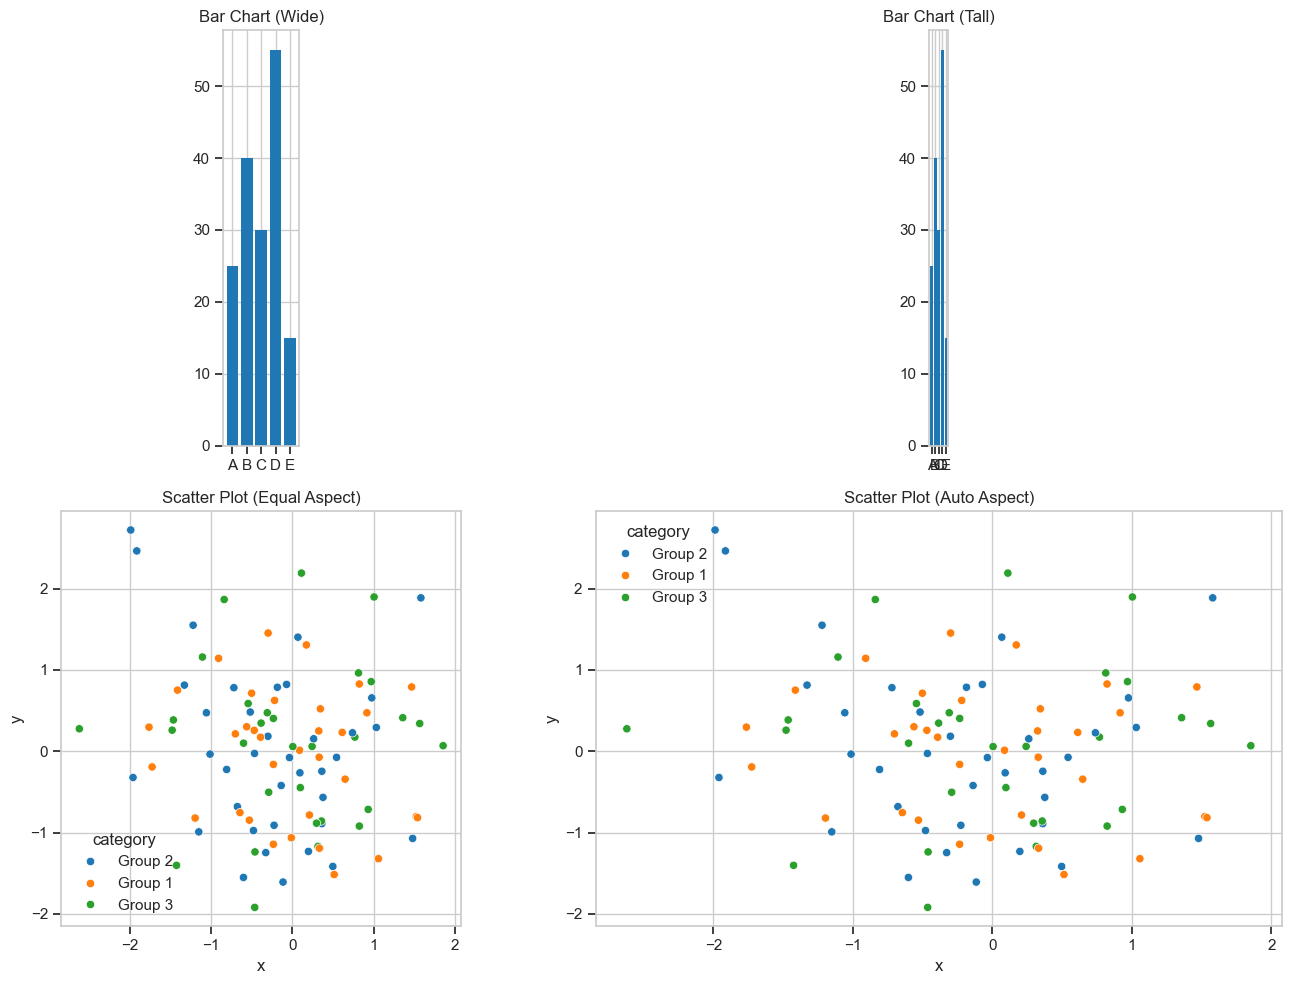

In [3]:
# Create a dataset for bar chart
categories = ['A', 'B', 'C', 'D', 'E']
values = [25, 40, 30, 55, 15]

# Create a dataset for scatter plot
np.random.seed(42)
data = pd.DataFrame({
    'x': np.random.normal(0, 1, 100),
    'y': np.random.normal(0, 1, 100),
    'category': np.random.choice(['Group 1', 'Group 2', 'Group 3'], 100)
})

# Create a 2x2 grid to show different plot types with different sizes
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Bar chart with default aspect ratio
axs[0, 0].bar(categories, values)
axs[0, 0].set_title('Bar Chart (Wide)')
axs[0, 0].set_aspect(0.5)  # Wide aspect

# Bar chart with tall aspect ratio
axs[0, 1].bar(categories, values)
axs[0, 1].set_title('Bar Chart (Tall)')
axs[0, 1].set_aspect(2)  # Tall aspect

# Scatter plot with default aspect ratio
sns.scatterplot(x='x', y='y', hue='category', data=data, ax=axs[1, 0])
axs[1, 0].set_title('Scatter Plot (Equal Aspect)')
axs[1, 0].set_aspect('equal')  # Equal aspect ratio

# Scatter plot with adjusted aspect ratio
sns.scatterplot(x='x', y='y', hue='category', data=data, ax=axs[1, 1])
axs[1, 1].set_title('Scatter Plot (Auto Aspect)')
axs[1, 1].set_aspect('auto')  # Auto aspect

plt.tight_layout()
plt.show()

## Controlling Figure Resolution

The resolution of a figure determines how sharp and clear the visualization appears, particularly when saved to a file or printed. In Matplotlib, resolution is controlled by the DPI (dots per inch) parameter.

There are two important DPI settings to understand:

1. **Figure DPI** (`figure.dpi`): Controls the resolution of the figure on screen
2. **Save DPI** (`savefig.dpi`): Controls the resolution of saved figures

Higher DPI values result in clearer images but larger file sizes.

Current screen DPI setting: 100.0
Current save DPI setting: figure


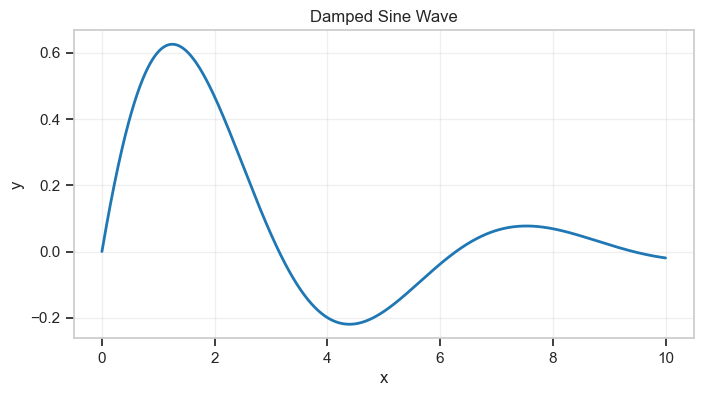

In [4]:
# Create a simple line plot
plt.figure(figsize=(8, 4))
x = np.linspace(0, 10, 1000)
y = np.sin(x) * np.exp(-x/3)
plt.plot(x, y, linewidth=2)
plt.title('Damped Sine Wave')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)

# Display the current DPI settings
print(f"Current screen DPI setting: {plt.rcParams['figure.dpi']}")
print(f"Current save DPI setting: {plt.rcParams['savefig.dpi']}")

plt.show()

### Adjusting DPI Settings

Let's save the same figure with different DPI settings to see the effect on image quality:

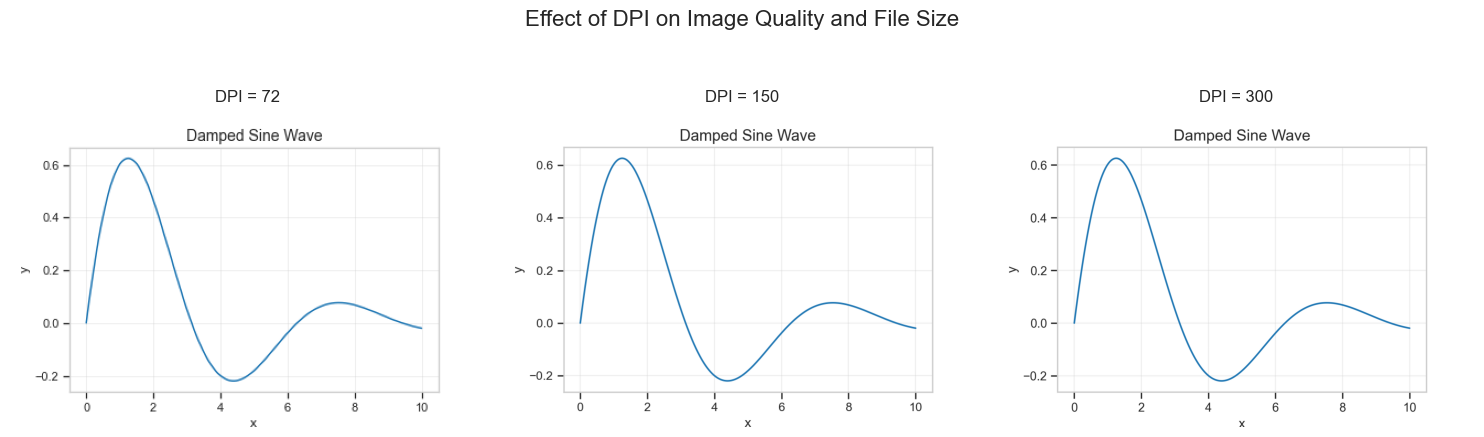

In [5]:
# Create a figure with detailed elements to show resolution differences
def create_detailed_figure():
    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.linspace(0, 10, 1000)
    y = np.sin(x) * np.exp(-x/3)
    ax.plot(x, y, linewidth=1.5)
    ax.set_title('Damped Sine Wave', fontsize=14)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.annotate('Peak', xy=(1.5, 0.8), xytext=(3, 0.9),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))
    return fig

# Save with different DPI settings
dpi_settings = [72, 150, 300]
file_names = []

for dpi in dpi_settings:
    fig = create_detailed_figure()
    filename = f"damped_sine_dpi_{dpi}.png"
    fig.savefig(filename, dpi=dpi)
    file_names.append(filename)
    plt.close(fig)

# Display a comparison of the saved figures
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, (dpi, filename) in enumerate(zip(dpi_settings, file_names)):
    img = plt.imread(filename)
    axs[i].imshow(img)
    axs[i].set_title(f"DPI = {dpi}")
    axs[i].axis('off')
    
    # Display file size
    import os
    file_size = os.path.getsize(filename) / 1024  # Size in KB
    axs[i].set_xlabel(f"File size: {file_size:.1f} KB")

plt.suptitle("Effect of DPI on Image Quality and File Size", fontsize=16)
plt.tight_layout()
plt.show()

## DPI and Export Settings

Different output formats and purposes require different DPI settings. Here's a guide:

- **Web/Screen Display**: 72-150 DPI is typically sufficient
- **Standard Printing**: 150-300 DPI provides good quality
- **High-quality Publication**: 300-600 DPI is often required
- **Posters**: 150-300 DPI depends on viewing distance

Let's compare different file formats (PNG, SVG, PDF, JPEG) with varying DPI settings:

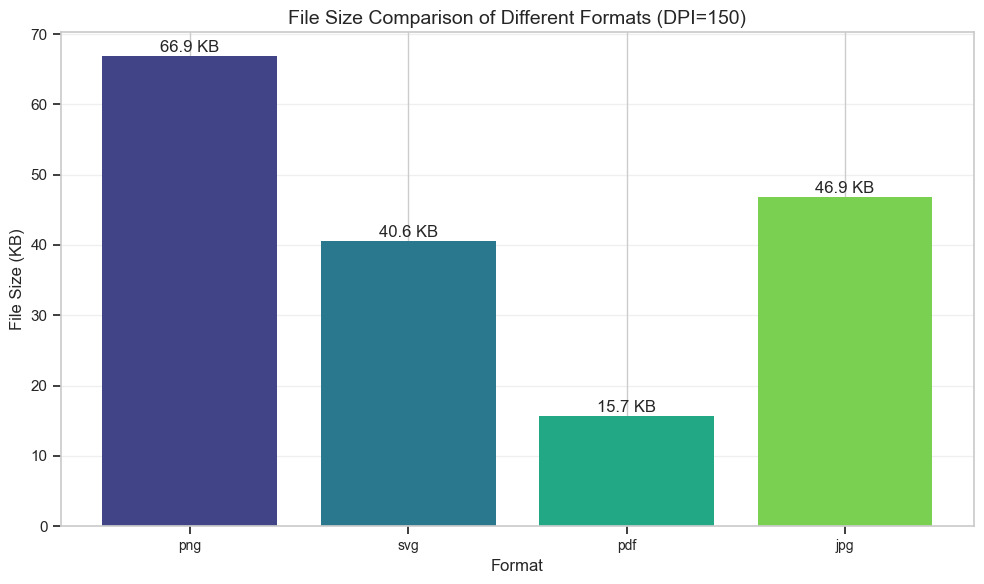

In [6]:
# Create a figure to export
def create_test_figure():
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Create some interesting content
    x = np.linspace(0, 10, 100)
    ax.plot(x, np.sin(x), label='sin(x)', linewidth=2)
    ax.plot(x, np.cos(x), label='cos(x)', linewidth=2)
    ax.fill_between(x, np.sin(x), alpha=0.2)
    
    ax.set_title('Sine and Cosine Functions', fontsize=14)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    return fig

# Export in different formats
formats = ['png', 'svg', 'pdf', 'jpg']
dpi = 150

file_sizes = {}

for fmt in formats:
    filename = f"test_figure.{fmt}"
    fig = create_test_figure()
    fig.savefig(filename, format=fmt, dpi=dpi)
    plt.close(fig)
    
    # Get file size
    import os
    file_size = os.path.getsize(filename) / 1024  # KB
    file_sizes[fmt] = file_size

# Display file size comparison
formats_list = list(file_sizes.keys())
sizes = list(file_sizes.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(formats_list, sizes, color=sns.color_palette("viridis", len(formats)))

# Add the values on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f} KB', ha='center', va='bottom')

plt.title('File Size Comparison of Different Formats (DPI=150)', fontsize=14)
plt.ylabel('File Size (KB)', fontsize=12)
plt.xlabel('Format', fontsize=12)
plt.xticks(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Format Comparison

| Format | Advantages | Disadvantages | Best For |
|--------|------------|---------------|----------|
| **PNG** | Lossless, transparent background | Larger file size for complex plots | Web, screenshots, raster needs |
| **SVG** | Vector format, scales without loss, editable | Not ideal for complex visualizations with many elements | Web, presentations, further editing |
| **PDF** | Vector format, preserves quality at any size | Requires PDF reader | Publications, printing, archiving |
| **JPEG** | Small file size | Lossy compression, no transparency | Photos, web when file size matters |

## Responsive Sizing for Different Outputs

Creating visualizations that look good across different display environments is important. Let's explore techniques for responsive sizing:

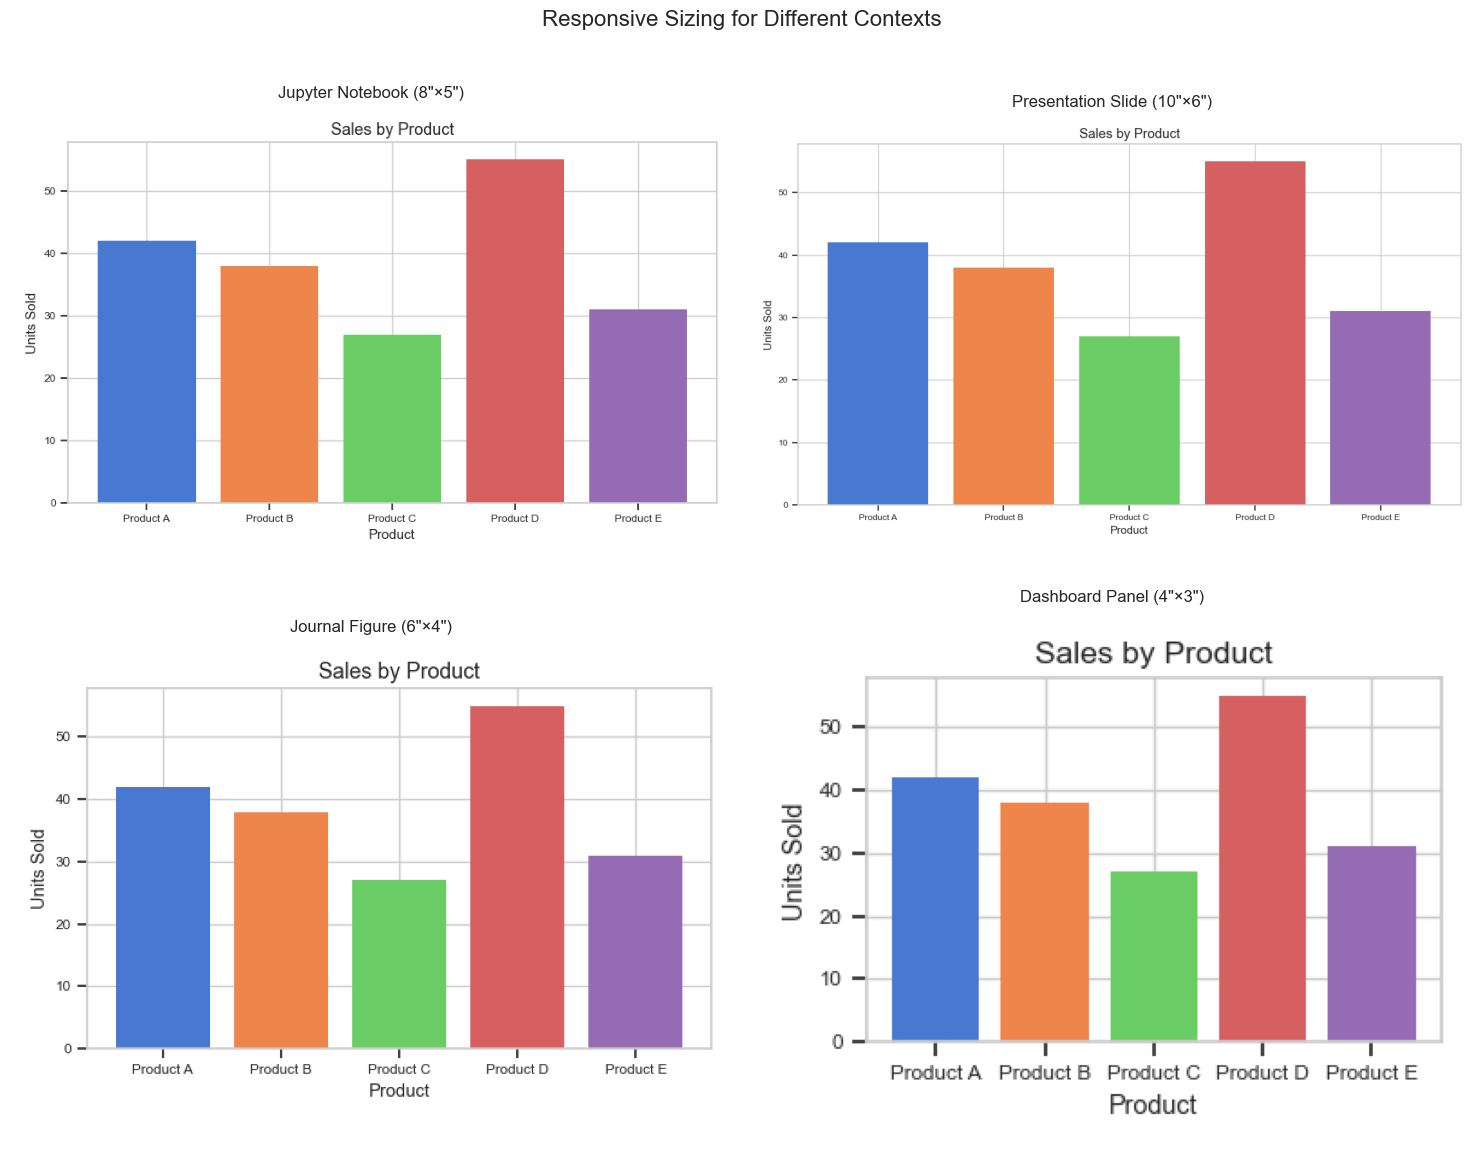

In [7]:
# Function to demonstrate responsive sizing
def create_responsive_plot(width_inches, height_inches, dpi=100):
    fig = plt.figure(figsize=(width_inches, height_inches), dpi=dpi)
    
    # Create sample data
    categories = ['Product A', 'Product B', 'Product C', 'Product D', 'Product E']
    values = [42, 38, 27, 55, 31]
    
    plt.bar(categories, values, color=sns.color_palette("muted"))
    plt.title('Sales by Product', fontsize=12+(width_inches/8))  # Dynamic title size
    plt.xlabel('Product', fontsize=10+(width_inches/10))
    plt.ylabel('Units Sold', fontsize=10+(width_inches/10))
    
    # Adjust text size based on figure size
    plt.xticks(fontsize=8+(width_inches/12))
    plt.yticks(fontsize=8+(width_inches/12))
    
    # Adjust layout
    plt.tight_layout()
    
    return fig

# Create plots for different contexts
contexts = {
    "Jupyter Notebook": (8, 5),
    "Presentation Slide": (10, 6),
    "Journal Figure": (6, 4),
    "Dashboard Panel": (4, 3)
}

# Display the plots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs = axs.flatten()

for i, (context, dimensions) in enumerate(contexts.items()):
    # Create a responsive figure for this context
    responsive_fig = create_responsive_plot(*dimensions)
    
    # Save to a temporary file
    responsive_fig.savefig(f"responsive_{i}.png", dpi=100)
    plt.close(responsive_fig)
    
    # Display in our main figure
    img = plt.imread(f"responsive_{i}.png")
    axs[i].imshow(img)
    axs[i].set_title(f"{context} ({dimensions[0]}\"×{dimensions[1]}\")", fontsize=12)
    axs[i].axis('off')

plt.suptitle("Responsive Sizing for Different Contexts", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

### Tips for Responsive Visualization

1. **Define size relative to content**: More complex visualizations generally need more space
2. **Use relative font sizes**: Scale font sizes based on figure dimensions
3. **Test in target environment**: Always preview in the intended display context
4. **Consider aspect ratios**: Maintain appropriate width-to-height ratios for your data
5. **Use tight_layout()**: Automatically adjust padding between plot elements

## Size and Resolution for Different Plot Types

Different types of visualizations have different size and resolution requirements. Let's explore what works best for various common plot types:

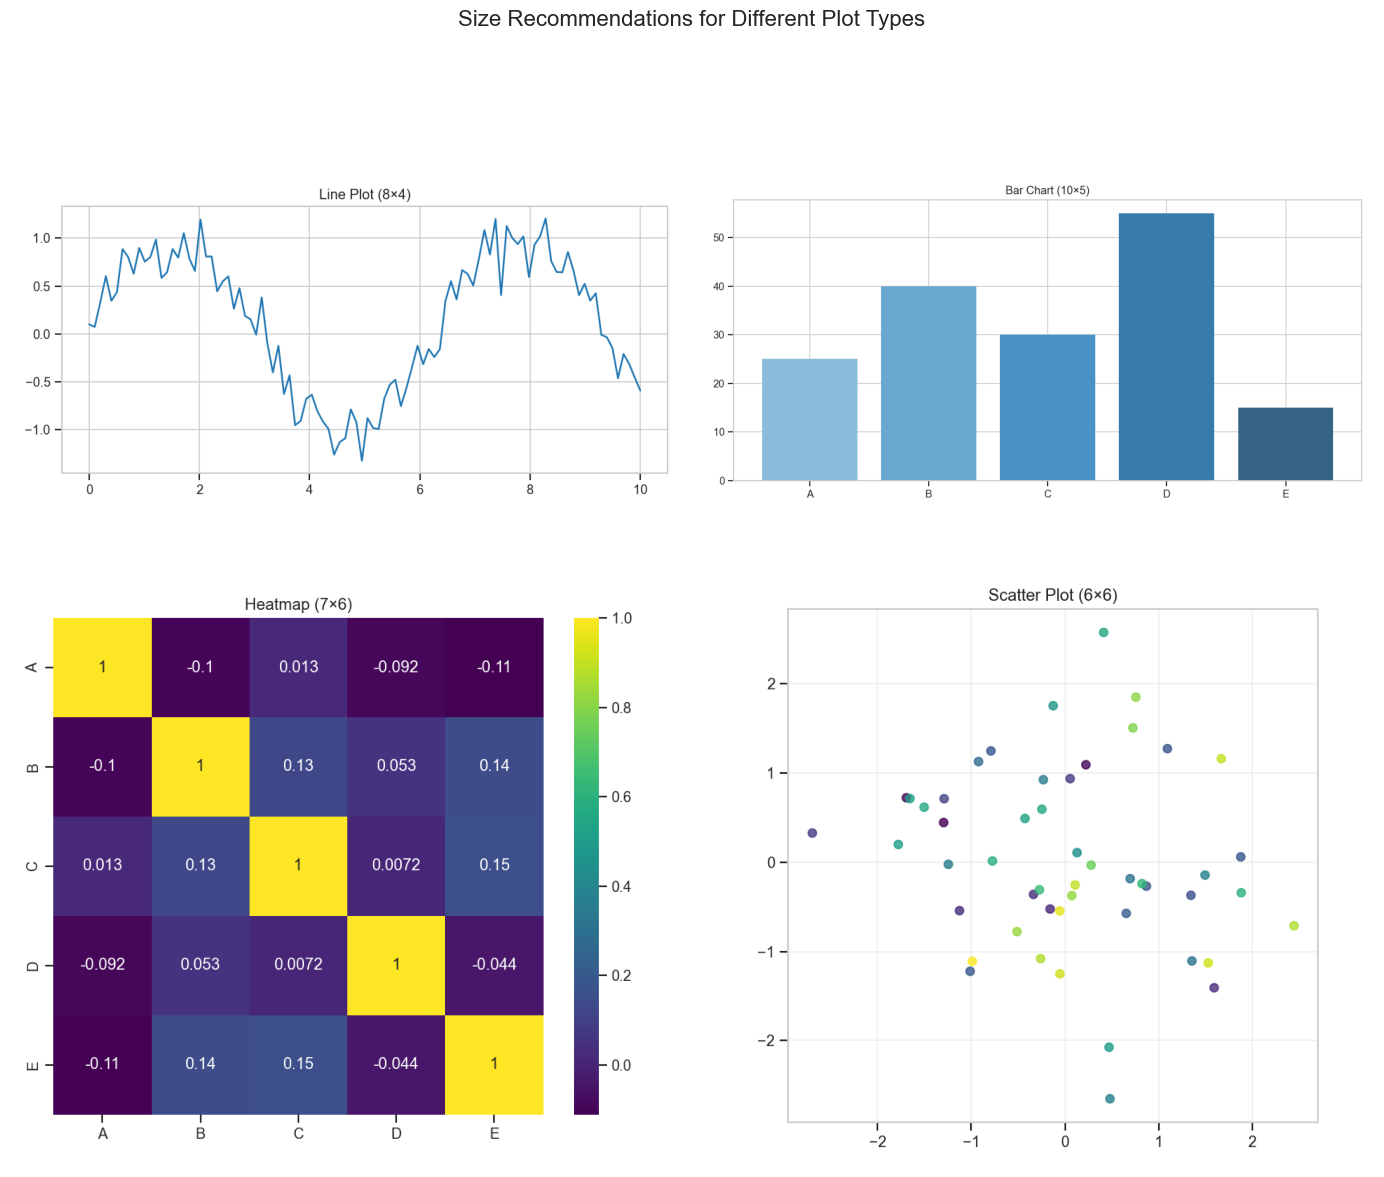

In [8]:
# Create sample data for different plot types
np.random.seed(42)
x = np.linspace(0, 10, 100)
y = np.sin(x) + 0.2 * np.random.randn(100)
categories = ['A', 'B', 'C', 'D', 'E']
values = [25, 40, 30, 55, 15]

# Create correlation matrix for heatmap
corr_data = pd.DataFrame(np.random.randn(100, 5), columns=['A', 'B', 'C', 'D', 'E'])
corr_matrix = corr_data.corr()

# Create a function to generate different plot types with appropriate sizes
def create_plot_examples():
    # Line plot - standard size often works well
    fig_line = plt.figure(figsize=(8, 4))
    plt.plot(x, y)
    plt.title('Line Plot (8×4)')
    plt.tight_layout()
    fig_line.savefig('line_plot.png', dpi=120)
    plt.close(fig_line)
    
    # Bar chart - often better with more width than height
    fig_bar = plt.figure(figsize=(10, 5))
    plt.bar(categories, values, color=sns.color_palette("Blues_d"))
    plt.title('Bar Chart (10×5)')
    plt.tight_layout()
    fig_bar.savefig('bar_plot.png', dpi=120)
    plt.close(fig_bar)
    
    # Heatmap - often square works best
    fig_heatmap = plt.figure(figsize=(7, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='viridis')
    plt.title('Heatmap (7×6)')
    plt.tight_layout()
    fig_heatmap.savefig('heatmap.png', dpi=120)
    plt.close(fig_heatmap)
    
    # Scatter plot - square is often preferred to maintain proper aspect ratio
    fig_scatter = plt.figure(figsize=(6, 6))
    plt.scatter(np.random.randn(50), np.random.randn(50), 
               c=np.random.rand(50), cmap='viridis', alpha=0.8)
    plt.title('Scatter Plot (6×6)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fig_scatter.savefig('scatter_plot.png', dpi=120)
    plt.close(fig_scatter)
    
    # Return filenames
    return ['line_plot.png', 'bar_plot.png', 'heatmap.png', 'scatter_plot.png']

# Generate the plots
plot_files = create_plot_examples()

# Display the plots
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
axs = axs.flatten()

for i, filename in enumerate(plot_files):
    img = plt.imread(filename)
    axs[i].imshow(img)
    axs[i].axis('off')

plt.suptitle("Size Recommendations for Different Plot Types", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

### Size Recommendations by Plot Type

| Plot Type | Recommended Size | Aspect Ratio | Notes |
|-----------|------------------|--------------|-------|
| Line plots | 8×4 to 10×6 | ~2:1 | Wider than tall to show trend over time |
| Bar charts | 10×5 to 12×6 | ~2:1 | Width depends on number of categories |
| Scatter plots | 6×6 to 8×8 | 1:1 | Square to maintain equal scaling on both axes |
| Heatmaps | 7×6 to 10×8 | Variable | Depends on matrix dimensions |
| Box plots | 8×6 | Variable | Width depends on number of categories |
| Histograms | 8×5 | ~1.6:1 | Width depends on number of bins |
| Pie charts | 6×6 | 1:1 | Square for proper circular appearance |
| Facet grids | 12×10 to 15×12 | Variable | Depends on number of subplots |

## Working with Complex Multi-Panel Figures

Complex visualizations with multiple subplots require special consideration for size and layout:

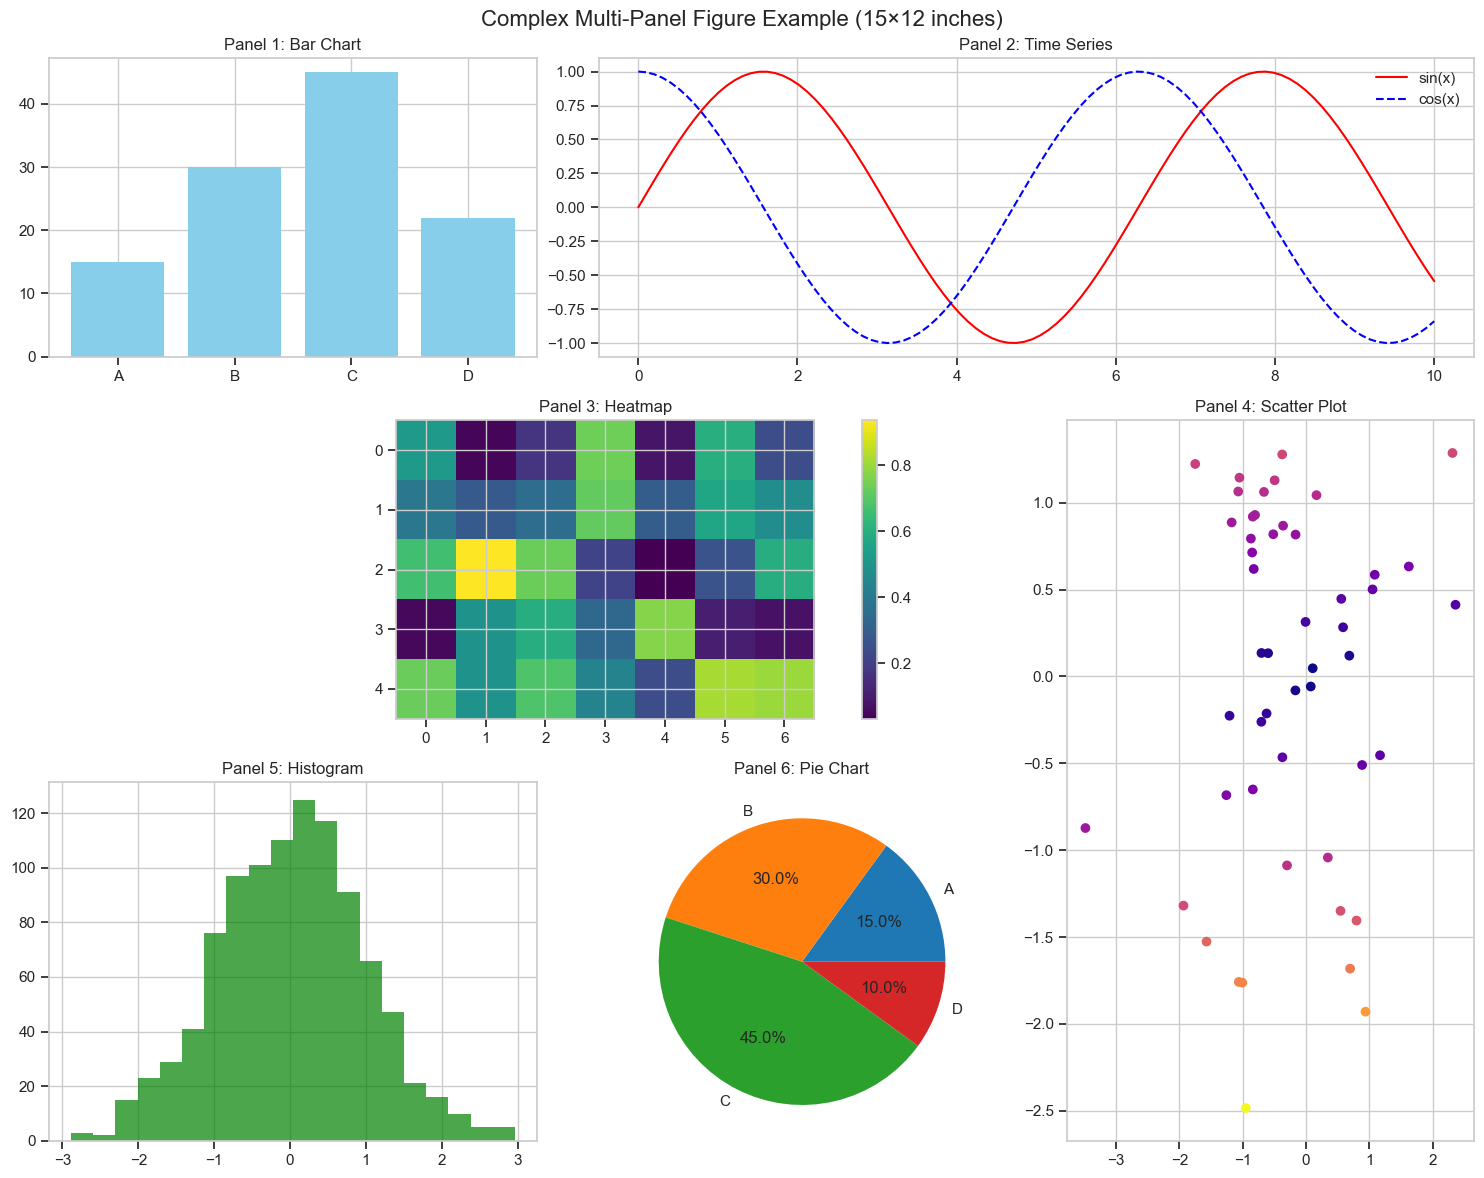

In [9]:
# Create a complex multi-panel figure
fig = plt.figure(figsize=(15, 12))

# Define a grid specification
gs = plt.GridSpec(3, 3, figure=fig, height_ratios=[1, 1, 1.2], width_ratios=[1.2, 1, 1])

# Add subplots at specific grid positions
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1:])
ax3 = fig.add_subplot(gs[1, :2])
ax4 = fig.add_subplot(gs[1:, 2])
ax5 = fig.add_subplot(gs[2, 0])
ax6 = fig.add_subplot(gs[2, 1])

# Add content to each subplot
# Panel 1: Bar chart
categories = ['A', 'B', 'C', 'D']
values = [15, 30, 45, 22]
ax1.bar(categories, values, color='skyblue')
ax1.set_title('Panel 1: Bar Chart')

# Panel 2: Line plot
x = np.linspace(0, 10, 100)
ax2.plot(x, np.sin(x), 'r-', label='sin(x)')
ax2.plot(x, np.cos(x), 'b--', label='cos(x)')
ax2.legend()
ax2.set_title('Panel 2: Time Series')

# Panel 3: Heatmap
data = np.random.rand(5, 7)
im = ax3.imshow(data, cmap='viridis')
fig.colorbar(im, ax=ax3)
ax3.set_title('Panel 3: Heatmap')

# Panel 4: Vertical scatter plot
y = np.random.randn(50)
x = np.random.randn(50)
ax4.scatter(x, y, c=np.abs(y), cmap='plasma')
ax4.set_title('Panel 4: Scatter Plot')

# Panel 5: Histogram
data = np.random.normal(0, 1, 1000)
ax5.hist(data, bins=20, alpha=0.7, color='green')
ax5.set_title('Panel 5: Histogram')

# Panel 6: Pie chart
sizes = [15, 30, 45, 10]
ax6.pie(sizes, labels=['A', 'B', 'C', 'D'], autopct='%1.1f%%')
ax6.set_title('Panel 6: Pie Chart')

# Adjust spacing
plt.tight_layout()
plt.suptitle('Complex Multi-Panel Figure Example (15×12 inches)', fontsize=16, y=0.98)
plt.subplots_adjust(top=0.94)

# Show the figure
plt.show()

### Tips for Multi-Panel Figures

1. **Plan your layout**: Sketch the layout before implementing it
2. **Use GridSpec**: For complex arrangements beyond simple grid layouts
3. **Balance panel sizes**: Allocate more space to more complex or important visualizations
4. **Consistent styling**: Maintain consistent colors, fonts, and styles across panels
5. **Clear labeling**: Add panel labels (A, B, C) for easy reference in publications
6. **Mind the spacing**: Use `tight_layout()` and `subplots_adjust()` to control spacing
7. **Consider the overall size**: Multi-panel figures need larger overall dimensions

## Best Practices for Publication-Quality Figures

Creating publication-ready visualizations requires careful attention to figure size, resolution, and formatting requirements. Here are best practices to follow:

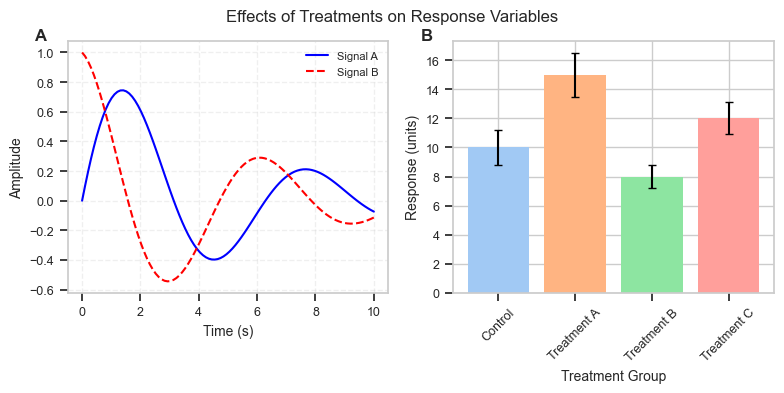

In [10]:
# Create a demonstration of publication-quality figures
def create_publication_figure():
    # Create a figure with appropriate dimensions for a journal
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    
    # Panel A: Simple line plot with proper formatting
    x = np.linspace(0, 10, 100)
    y1 = np.sin(x) * np.exp(-x/5)
    y2 = np.cos(x) * np.exp(-x/5)
    
    axs[0].plot(x, y1, 'b-', linewidth=1.5, label='Signal A')
    axs[0].plot(x, y2, 'r--', linewidth=1.5, label='Signal B')
    axs[0].set_xlabel('Time (s)', fontsize=10)
    axs[0].set_ylabel('Amplitude', fontsize=10)
    axs[0].tick_params(axis='both', which='major', labelsize=9)
    axs[0].legend(fontsize=8)
    axs[0].grid(True, alpha=0.3, linestyle='--')
    
    # Panel B: Bar chart with error bars
    categories = ['Control', 'Treatment A', 'Treatment B', 'Treatment C']
    values = [10, 15, 8, 12]
    errors = [1.2, 1.5, 0.8, 1.1]
    
    axs[1].bar(categories, values, yerr=errors, capsize=3, color=sns.color_palette("pastel")[0:4])
    axs[1].set_xlabel('Treatment Group', fontsize=10)
    axs[1].set_ylabel('Response (units)', fontsize=10)
    axs[1].tick_params(axis='both', which='major', labelsize=9)
    axs[1].tick_params(axis='x', rotation=45)
    
    # Add panel labels
    axs[0].text(-0.1, 1.05, 'A', transform=axs[0].transAxes, 
                fontsize=12, fontweight='bold', va='top')
    axs[1].text(-0.1, 1.05, 'B', transform=axs[1].transAxes, 
                fontsize=12, fontweight='bold', va='top')
    
    # Title for the entire figure
    fig.suptitle('Effects of Treatments on Response Variables', fontsize=12)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    
    return fig

# Create and display the publication figure
pub_fig = create_publication_figure()
plt.show()

# Save with publication-quality settings
pub_fig.savefig('publication_figure.png', dpi=300, bbox_inches='tight')
pub_fig.savefig('publication_figure.pdf', dpi=300, bbox_inches='tight')
pub_fig.savefig('publication_figure.svg', bbox_inches='tight')

### Journal Requirements for Figures

Most academic journals have specific requirements for figures. Here are common specifications:

| Journal Type | Common Requirements |
|--------------|---------------------|
| Medical/Scientific | 300-600 DPI, TIFF/PDF format, width: 85-180mm |
| Computer Science | 300 DPI, PDF/EPS format, one/two-column width |
| Economics | 300-600 DPI, PDF/EPS, often monochrome requirements |
| Engineering | 300+ DPI, vector formats preferred, specific dimension guidelines |

### Best Practices for Publication Figures

1. **Check specific requirements**: Always review the journal's author guidelines
2. **Use vector formats when possible**: SVG, PDF, or EPS preserve quality at any size
3. **Maintain consistent fonts**: Use standard fonts that are widely available
4. **Make text legible**: Text should remain readable when figure is resized
5. **Optimize for colorblind readers**: Use colorblind-friendly palettes
6. **Label panels clearly**: Use A, B, C labels for multi-panel figures
7. **Provide high resolution**: Minimum 300 DPI for print publication
8. **Consider figure width constraints**: Single-column vs. double-column figures
9. **Provide separate figure legends**: When required by the journal
10. **Use tight bounding boxes**: Remove unnecessary whitespace with `bbox_inches='tight'`

## Conclusion

Controlling figure size and resolution is essential for creating effective visualizations. Key takeaways include:

1. **Match figure size to content**: Different plot types have different optimal sizes and aspect ratios
2. **Set appropriate DPI**: Higher for publication (300+ DPI), lower for web/screen (72-150 DPI)
3. **Choose the right file format**: Vector formats (SVG, PDF) for scalability, raster formats (PNG) for web
4. **Consider the output medium**: Adjust dimensions based on where the figure will be displayed
5. **Use responsive design techniques**: Scale elements proportionally when figure size changes
6. **Follow publication guidelines**: When preparing figures for journals or books

By applying these principles, you can create visualizations that are clear, professional, and appropriate for your intended audience.

In [11]:
# # Clean up temporary files
# import os
# import glob

# # Remove temporary image files
# for filename in glob.glob("temp_fig_size_*.png"):
#     os.remove(filename)
# for filename in glob.glob("responsive_*.png"):
#     os.remove(filename)
# for filename in glob.glob("*_plot.png"):
#     os.remove(filename)
# for filename in glob.glob("test_figure.*"):
#     os.remove(filename)

# print("Temporary files cleaned up!")